# REQUIREMENTS

In [ ]:
!pip install umap-learn

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import umap
import time

# ___________________________________

#**Dimesionality reduction**


testing techniques with 20 similar feature

In [ ]:
weather_features = [
    'temp_Madrid', 'pressure_Madrid', 'humidity_Madrid', 'wind_speed_Madrid',
    'temp_Bilbao', 'pressure_Bilbao', 'humidity_Bilbao', 'wind_speed_Bilbao',
    'temp_Seville', 'pressure_Seville', 'humidity_Seville', 'wind_speed_Seville',
    'temp_Barcelona', 'pressure_Barcelona', 'humidity_Barcelona', 'wind_speed_Barcelona',
    'temp_Valencia', 'pressure_Valencia', 'humidity_Valencia', 'wind_speed_Valencia'
]

len(weather_features)

20

In [ ]:
# Loading and preparing the data
# https://drive.google.com/file/d/1bptVfwvA0PCmT3dQj61dXkJ4CQsUrGgj/view?usp=sharing


data = pd.read_csv('https://drive.google.com/uc?export=download&id=1bptVfwvA0PCmT3dQj61dXkJ4CQsUrGgj', parse_dates=['time'])
features = weather_features
X = data[features]
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
## PCA
start_time = time.time()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_time = time.time() - start_time
print(f'PCA variance ratio: {pca.explained_variance_ratio_}')

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
tsne_time = time.time() - start_time

# UMAP
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)
umap_time = time.time() - start_time

# Printing execution times
print(f'PCA execution time: {pca_time:.2f} seconds')
print(f't-SNE execution time: {tsne_time:.2f} seconds')
print(f'UMAP execution time: {umap_time:.2f} seconds')


PCA variance ratio: [0.32000734 0.16277032]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA execution time: 0.04 seconds
t-SNE execution time: 455.12 seconds
UMAP execution time: 517.75 seconds


In [ ]:
# All 45 features
all_weather_features = [
    'temp_Madrid', 'pressure_Madrid', 'humidity_Madrid', 'wind_speed_Madrid','wind_deg_Madrid', 'clouds_all_Madrid','rain_1h_Madrid', 'rain_3h_Madrid', 'snow_3h_Madrid',
    'temp_Bilbao', 'pressure_Bilbao', 'humidity_Bilbao', 'wind_speed_Bilbao', 'wind_deg_Bilbao', 'clouds_all_Bilbao','rain_1h_Bilbao', 'rain_3h_Bilbao', 'snow_3h_Bilbao',
    'temp_Seville', 'pressure_Seville', 'humidity_Seville', 'wind_speed_Seville', 'wind_deg_Seville', 'clouds_all_Seville','rain_1h_Seville', 'rain_3h_Seville', 'snow_3h_Seville',
    'temp_Barcelona', 'pressure_Barcelona', 'humidity_Barcelona', 'wind_speed_Barcelona', 'wind_deg_Barcelona', 'clouds_all_Barcelona','rain_1h_Barcelona', 'rain_3h_Barcelona', 'snow_3h_Barcelona',
    'temp_Valencia', 'pressure_Valencia', 'humidity_Valencia', 'wind_speed_Valencia' , 'wind_deg_Valencia', 'clouds_all_Valencia','rain_1h_Valencia', 'rain_3h_Valencia','snow_3h_Valencia'
]
len(all_weather_features)


45

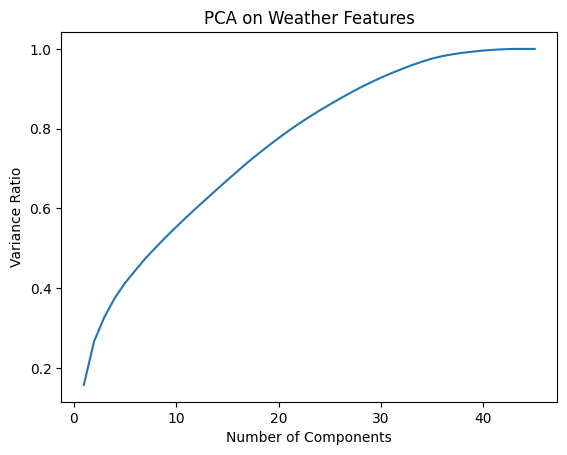

In [ ]:

X = data[all_weather_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca_result = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)


plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio)
plt.xlabel('Number of Components')
plt.ylabel('Variance Ratio')
plt.title('PCA on Weather Features')
plt.show()


In [ ]:
cumulative_variance_ratio

# we can see from here that 33 is the number of components needed to rach 95%.

array([0.15715724, 0.26625406, 0.32701202, 0.37422739, 0.412164  ,
       0.44363613, 0.47430962, 0.50135806, 0.5280119 , 0.55304111,
       0.57769258, 0.60160388, 0.6248109 , 0.64793357, 0.6708982 ,
       0.69335296, 0.71564453, 0.73651939, 0.75673347, 0.7760483 ,
       0.7949509 , 0.81274085, 0.82943014, 0.84543167, 0.86061577,
       0.87537889, 0.88965072, 0.90336444, 0.91593355, 0.92793147,
       0.93901952, 0.9493093 , 0.95917594, 0.9679463 , 0.97604745,
       0.98198156, 0.98658123, 0.99042481, 0.99338478, 0.99594321,
       0.99786096, 0.99915329, 1.        , 1.        , 1.        ])

In [ ]:
# Initialising
first_index = -1

# Looping through the list
for i in range(len(cumulative_variance_ratio)):
    if cumulative_variance_ratio[i] >= 0.95:
        first_index = i
        break

n = first_index+1

print("The index of the first component to reach 0.95 is:", n)

The index of the first component to reach 0.95 is: 33


In [ ]:
# fitting PCA
pca = PCA(n_components=n)
reduced_weather_data = pca.fit_transform(X_scaled)


In [ ]:
reduced_weather_df = pd.DataFrame(
    reduced_weather_data,
    columns=[f'weather_pc_{i+1}' for i in range(n)]
)
data.shape

(35064, 63)

In [ ]:

final_data = pd.concat([data.drop(columns=all_weather_features).reset_index(drop=True),
                               reduced_weather_df.reset_index(drop=True)],
                              axis=1)
final_data.shape

(35064, 51)

In [ ]:
# shape of the dataset after reducing
final_data.dropna(inplace=True)
final_data.shape

(35064, 51)

In [ ]:
final_data.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,...,weather_pc_24,weather_pc_25,weather_pc_26,weather_pc_27,weather_pc_28,weather_pc_29,weather_pc_30,weather_pc_31,weather_pc_32,weather_pc_33
0,2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,...,-2.474905,1.422926,-0.362023,0.444314,-1.363135,-0.000535,0.914587,0.078107,0.641325,0.504795
1,2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,...,-2.484197,1.417555,-0.368429,0.445629,-1.364634,-0.005900,0.909228,0.083296,0.646697,0.487433
2,2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,...,-2.496708,1.413434,-0.379636,0.646797,-1.159690,-0.411598,0.696686,0.001335,0.461813,0.360853
3,2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,...,-2.505570,1.407821,-0.382255,0.648413,-1.160812,-0.414129,0.689422,0.003517,0.465343,0.346420
4,2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,...,-2.498216,1.406796,-0.370199,0.657943,-1.159345,-0.412173,0.677983,0.000872,0.451237,0.337669


In [ ]:
final_data.to_csv('reduced_data.csv')

from google.colab import files
files.download('reduced_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>